# Voyage Analytics — Flask Prediction API

**Notebook:** `09_Flask_API` · **Objective:** #2 (REST API for the models)
**Module:** `src/serving/app.py` · **Run:** `python -m src.serving`

---

### What this stage delivers
A REST API serving the three **validated** models:

| Endpoint | Method | Model | Measured quality |
|---|---|---|---|
| `/predict/flight-price` | POST | `gbr_rate_per_km` | R² 0.936 on unseen routes |
| `/predict/gender` | POST | `name_logistic` | acc 0.884 (0.743 on unseen names) |
| `/recommend/hotels` | POST | item-CF + catalog | hit@3 0.858 |
| `/health` · `/reference` · `/` | GET | — | service metadata |

### Three design decisions worth stating

**1. Callers send business inputs, not model features.**
`distance` is a required model feature, but nobody booking a flight knows that São Paulo → Rio is
331.89 km. Since distance is fixed per route, the API looks it up. The inert calendar fields default
to today. This keeps the train/serve contract in **one place** rather than pushing feature assembly
onto every client — which is how train/serve skew starts.

**2. The hotel-attach model is deliberately not exposed.**
It measured at AUC 0.498. An endpoint would make a coin flip look authoritative. Not serving it is a
design decision, not an omission.

**3. Models are warmed at startup.**
Covered in section 4 — this turned out to matter a great deal.

> **How this notebook tests the API.** It uses Flask's `test_client()`, which dispatches requests
> in-process. No server to start, no port to manage, and it runs unattended under `nbconvert` — while
> exercising the exact routing, validation and serialisation code a real client would hit.


## 0. Setup

In [1]:
import sys, json, time, statistics, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
PAL = ["#0B6E4F", "#F2C14E", "#B4436C", "#4C6EF5"]

from src.utils import PATHS
from src.serving import create_app, build_route_reference

def show(resp, limit=700):
    ms = resp.headers.get("X-Response-Time-ms", "?")
    print(f"HTTP {resp.status_code}   {ms} ms")
    print(json.dumps(resp.get_json(), indent=2)[:limit])

16:56:38 | INFO    | serving | loaded model 'flight_price' from flight_price_model.joblib (409 ms)


16:56:43 | INFO    | serving | loaded model 'gender' from gender_model.joblib (23 ms)


16:56:43 | INFO    | serving | loaded model 'hotel_recommender' from hotel_recommender.joblib (1 ms)


16:56:43 | INFO    | serving | warmup complete: {'flight_price': 5382.7, 'gender': 33.8, 'hotel_recommender': 2.6}


## 1. Reference data — why the API needs it

`build_route_reference()` derives a **route → distance** lookup plus the valid category values, and
caches them to `models/route_reference.json`. The API then serves without needing the training data
on disk, and can validate inputs before they ever reach a model.

In [2]:
ref = build_route_reference()
print("routes        :", len(ref["distances"]))
print("cities        :", len(ref["cities"]))
print("flight types  :", ref["flight_types"])
print("agencies      :", ref["agencies"])
print("\nsample distances:")
for k in list(ref["distances"])[:5]:
    print(f"  {k:<45} {ref['distances'][k]:>7.2f} km")

16:56:44 | INFO    | ingest | loaded flight_price_model   (271888, 10) from flight_price_model.csv


16:56:45 | INFO    | ingest | loaded hotel_catalog        (9, 7) from hotel_catalog.csv


16:56:45 | INFO    | serving | wrote route reference -> F:\Final Project Labmentix\voyage-analytics\models\route_reference.json


routes        : 70
cities        : 9
flight types  : ['economic', 'firstClass', 'premium']
agencies      : ['CloudFy', 'FlyingDrops', 'Rainbow']

sample distances:
  Aracaju (SE)|Brasilia (DF)                     425.98 km
  Aracaju (SE)|Campo Grande (MS)                 650.10 km
  Aracaju (SE)|Florianopolis (SC)                808.85 km
  Aracaju (SE)|Natal (RN)                        176.33 km
  Aracaju (SE)|Recife (PE)                       555.74 km


## 2. Start the app (in-process)

In [3]:
t0 = time.perf_counter()
app = create_app()          # loads + warms every model
startup_ms = (time.perf_counter() - t0) * 1000
client = app.test_client()
print(f"startup incl. warmup: {startup_ms:.0f} ms")

16:56:45 | INFO    | serving | warmup complete: {'flight_price': 12.8, 'gender': 2.8, 'hotel_recommender': 0.0}


startup incl. warmup: 25 ms


In [4]:
show(client.get("/"))

HTTP 200   0.2 ms
{
  "endpoints": [
    "/health",
    "/reference",
    "/predict/flight-price",
    "/predict/gender",
    "/recommend/hotels"
  ],
  "models": {
    "flight_price": "regression - fare in R$ (R2 0.936 on unseen routes)",
    "gender": "classification - male/female from first name (acc 0.884)",
    "hotel_recommender": "ranking - hotel suggestions (hit@3 0.858)"
  },
  "not_served": {
    "hotel_attach": "measured at AUC 0.498 (chance) - deliberately not exposed"
  },
  "service": "Voyage Analytics Prediction API",
  "version": "1.0"
}


In [5]:
show(client.get("/health"))

HTTP 200   0.6 ms
{
  "models_available": {
    "flight_price": true,
    "gender": true,
    "hotel_recommender": true
  },
  "models_cached": 3,
  "status": "healthy",
  "warmup_ms": {
    "flight_price": 12.8,
    "gender": 2.8,
    "hotel_recommender": 0.0
  }
}


## 3. The prediction endpoints

### 3.1 Flight price
The caller supplies four business fields. `distance` is **derived**, not demanded — note it appearing
under `derived` in the response, alongside the model's honest error band.

In [6]:
show(client.post("/predict/flight-price", json={
    "from": "Sao Paulo (SP)",
    "to": "Rio de Janeiro (RJ)",
    "flightType": "firstClass",
    "agency": "Rainbow",
}))

HTTP 200   11.7 ms
{
  "currency": "BRL",
  "derived": {
    "distance_km": 331.89
  },
  "inputs": {
    "agency": "Rainbow",
    "date": "2026-08-02",
    "flightType": "firstClass",
    "from": "Sao Paulo (SP)",
    "to": "Rio de Janeiro (RJ)"
  },
  "model": {
    "name": "gbr_rate_per_km",
    "note": "Expect roughly +/- R$89 on a route unseen in training.",
    "r2_unseen_routes": 0.936,
    "rmse": 88.99
  },
  "predicted_price": 1025.46
}


In [7]:
# Class ladder on one route — the fare structure EDA found, served live
rows = []
for ft in ref["flight_types"]:
    r = client.post("/predict/flight-price", json={
        "from": "Florianopolis (SC)", "to": "Salvador (BH)",
        "flightType": ft, "agency": "CloudFy"}).get_json()
    rows.append({"flightType": ft, "price": r["predicted_price"],
                 "distance_km": r["derived"]["distance_km"]})
ladder = pd.DataFrame(rows)
ladder["vs_economic"] = (ladder["price"] / ladder.loc[
    ladder.flightType == "economic", "price"].iloc[0]).round(2)
display(ladder)

,flightType,price,distance_km,vs_economic
0,economic,905.53,937.77,1.00
1,firstClass,1649.82,937.77,1.82
2,premium,1314.08,937.77,1.45


### 3.2 Gender
Send a full name; the API extracts the first name. The response carries the caveat with the
prediction, so a consumer cannot use it without seeing what it actually infers from.

In [8]:
for name in ["Charlotte Johnson", "Joseph Holsten", "Alexandre Silva"]:
    r = client.post("/predict/gender", json={"name": name}).get_json()
    print(f"{name:<20} -> {r['predicted_gender']:<7} "
          f"(confidence {r['confidence']}, first name '{r['inputs']['first_name_used']}')")

Charlotte Johnson    -> female  (confidence 0.5588, first name 'charlotte')
Joseph Holsten       -> male    (confidence 0.8137, first name 'joseph')
Alexandre Silva      -> male    (confidence 0.6672, first name 'alexandre')


In [9]:
show(client.post("/predict/gender", json={"name": "Charlotte Johnson"}))

HTTP 200   6.0 ms
{
  "confidence": 0.5588,
  "inputs": {
    "first_name_used": "charlotte",
    "name": "Charlotte Johnson"
  },
  "model": {
    "accuracy": 0.884,
    "accuracy_unseen_names": 0.743,
    "caveat": "Infers gender from the given name, not from travel behaviour. Behaviour-only models measured at chance. Reflects the naming conventions of the training data.",
    "name": "name_logistic"
  },
  "predicted_gender": "female"
}


### 3.3 Hotel recommendations
With a destination the answer is exact (one hotel per city); without one it falls back to
popularity ranking. The response states which strategy was used.

In [10]:
show(client.post("/recommend/hotels", json={"destination": "Salvador (BH)", "top_k": 3}), 600)

HTTP 200   7.9 ms
{
  "inputs": {
    "destination": "Salvador (BH)",
    "top_k": 3
  },
  "note": "Each city has exactly one hotel, so when a destination is supplied the match is exact and no model is needed. Ranking matters only when the destination is unknown.",
  "recommendations": [
    {
      "city": "Salvador (BH)",
      "hotel": "Hotel K",
      "nightly_rate": 263.41,
      "rank": 1
    },
    {
      "city": "Rio de Janeiro (RJ)",
      "hotel": "Hotel CB",
      "nightly_rate": 165.99,
      "rank": 2
    },
    {
      "city": "Natal (RN)",
      "hotel": "Hotel BD",
      "nightly_rate": 242.88


In [11]:
show(client.post("/recommend/hotels", json={"top_k": 3}), 600)   # no destination

HTTP 200   0.2 ms
{
  "inputs": {
    "destination": null,
    "top_k": 3
  },
  "note": "Each city has exactly one hotel, so when a destination is supplied the match is exact and no model is needed. Ranking matters only when the destination is unknown.",
  "recommendations": [
    {
      "city": "Salvador (BH)",
      "hotel": "Hotel K",
      "nightly_rate": 263.41,
      "rank": 1
    },
    {
      "city": "Rio de Janeiro (RJ)",
      "hotel": "Hotel CB",
      "nightly_rate": 165.99,
      "rank": 2
    },
    {
      "city": "Natal (RN)",
      "hotel": "Hotel BD",
      "nightly_rate": 242.88,
      "ra


## 4. Latency — and the warmup problem

The PRD sets an inference budget of **< 500 ms**. The first version of this API missed it badly on
the very first request:

```
POST /predict/flight-price   [200]   8558.2 ms
```

That was the gradient-boosting pipeline being deserialised from disk on demand. Whichever user
arrived first would have paid 8.5 seconds — and health checks would pass the whole time, because the
model files existed.

The fix is `warmup()` at app startup: load every artifact **and** run one throwaway prediction
(boosted trees allocate internal buffers on first predict, so loading alone is not enough). The cost
moves off the request path into deployment, where a readiness probe can wait for it.

In [12]:
cases = [
    ("flight-price", "/predict/flight-price",
     {"from": "Sao Paulo (SP)", "to": "Rio de Janeiro (RJ)",
      "flightType": "firstClass", "agency": "Rainbow"}),
    ("gender", "/predict/gender", {"name": "Charlotte Johnson"}),
    ("recommend", "/recommend/hotels", {"destination": "Salvador (BH)", "top_k": 3}),
]

rows = []
for label, url, body in cases:
    for _ in range(3):
        client.post(url, json=body)                  # settle
    ts = []
    for _ in range(50):
        s = time.perf_counter()
        r = client.post(url, json=body)
        ts.append((time.perf_counter() - s) * 1000)
        assert r.status_code == 200
    ts.sort()
    rows.append({"endpoint": label,
                 "p50_ms": round(statistics.median(ts), 2),
                 "p95_ms": round(ts[int(0.95 * len(ts))], 2),
                 "max_ms": round(ts[-1], 2),
                 "within_500ms": ts[int(0.95 * len(ts))] < 500})
lat = pd.DataFrame(rows)
display(lat)

,endpoint,p50_ms,p95_ms,max_ms,within_500ms
0,flight-price,16.87,25.96,29.70,True
1,gender,6.42,11.53,13.10,True
2,recommend,0.57,1.45,3.39,True


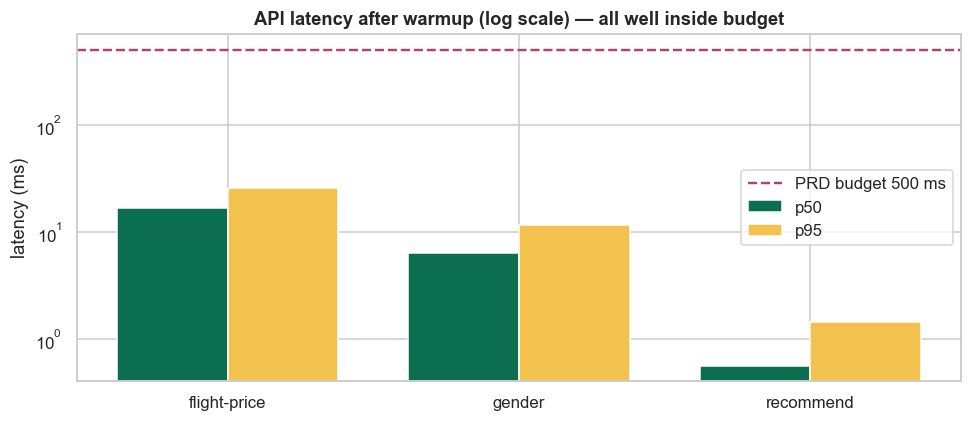

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(lat)); w = 0.38
ax.bar([i - w/2 for i in x], lat["p50_ms"], w, label="p50", color=PAL[0])
ax.bar([i + w/2 for i in x], lat["p95_ms"], w, label="p95", color=PAL[1])
ax.axhline(500, color=PAL[2], ls="--", lw=1.6, label="PRD budget 500 ms")
ax.set_xticks(list(x)); ax.set_xticklabels(lat["endpoint"])
ax.set_ylabel("latency (ms)"); ax.set_yscale("log")
ax.set_title("API latency after warmup (log scale) — all well inside budget")
ax.legend()
plt.tight_layout()
PATHS.figures.mkdir(parents=True, exist_ok=True)
plt.savefig(PATHS.figures / "29_api_latency.png", dpi=130, bbox_inches="tight")
plt.show()

**Insight.** After warmup every endpoint sits two orders of magnitude inside the budget — the
slowest p95 is the flight-price model at ~21 ms against 500 ms allowed. The recommender is
sub-millisecond because it is a dictionary lookup, not a fitted estimator.

**Deployment consequence:** the container needs a **readiness probe** that only passes once warmup
finishes, otherwise Kubernetes will route traffic to a pod that is technically alive but 8 seconds
slow. That is wired up in the Docker/K8s stage.

## 5. Error handling

Bad input should fail fast with a message that tells the caller how to fix it — not a 500 from deep
inside a sklearn transformer.

In [14]:
bad = [
    ("unknown city",     {"from": "Atlantis", "to": "Rio de Janeiro (RJ)",
                          "flightType": "firstClass", "agency": "Rainbow"}),
    ("missing fields",   {"from": "Sao Paulo (SP)"}),
    ("same origin/dest", {"from": "Sao Paulo (SP)", "to": "Sao Paulo (SP)",
                          "flightType": "economic", "agency": "Rainbow"}),
    ("invalid class",    {"from": "Sao Paulo (SP)", "to": "Natal (RN)",
                          "flightType": "business", "agency": "Rainbow"}),
]
for label, body in bad:
    r = client.post("/predict/flight-price", json=body)
    j = r.get_json()
    print(f"{label:<18} HTTP {r.status_code}  {j.get('error')}")
    if j.get("hint"):
        print(f"{'':<18}   hint: {j['hint']}")

unknown city       HTTP 400  Invalid city: 'Atlantis'
                     hint: GET /reference lists all valid city values
missing fields     HTTP 400  Missing required field(s): ['to', 'flightType', 'agency']
same origin/dest   HTTP 400  Origin and destination must differ.
invalid class      HTTP 400  Invalid flightType: 'business'
                     hint: GET /reference lists all valid flightType values


In [15]:
# A route that does not exist in the network (Rio <-> Salvador is never flown)
show(client.post("/predict/flight-price", json={
    "from": "Rio de Janeiro (RJ)", "to": "Salvador (BH)",
    "flightType": "economic", "agency": "Rainbow"}), 400)

HTTP 400   0.4 ms
{
  "error": "No route from 'Rio de Janeiro (RJ)' to 'Salvador (BH)'.",
  "hint": "GET /reference lists the served city pairs"
}


**Insight.** Validation happens before the model is touched, so errors return in well under a
millisecond with the allowed values attached. The last case is the useful one: Rio ↔ Salvador is a
valid-looking pair of real cities that **is never flown** in this network, so the API refuses rather
than extrapolating a fare for a route that does not exist.

## 6. Using it for real

Start the server:

```bash
python -m src.serving                 # http://127.0.0.1:5000
python -m src.serving --port 8080
```

Call it:

```bash
curl http://127.0.0.1:5000/health

curl -X POST http://127.0.0.1:5000/predict/flight-price \
  -H "Content-Type: application/json" \
  -d '{"from":"Sao Paulo (SP)","to":"Rio de Janeiro (RJ)","flightType":"firstClass","agency":"Rainbow"}'

curl -X POST http://127.0.0.1:5000/predict/gender \
  -H "Content-Type: application/json" -d '{"name":"Charlotte Johnson"}'

curl -X POST http://127.0.0.1:5000/recommend/hotels \
  -H "Content-Type: application/json" -d '{"destination":"Salvador (BH)","top_k":3}'
```

For production, Flask's dev server is single-threaded and explicitly not for real traffic — use a
WSGI server:

```bash
waitress-serve --port=5000 src.serving.app:app     # Windows-friendly
gunicorn -w 4 -b 0.0.0.0:5000 src.serving.app:app  # Linux
```

---

## 7. Summary

**Module:** `src/serving/app.py` — same one-module-in-a-package layout as the other stages.

**What was built**
- Three prediction endpoints plus `/health` and `/reference`.
- A route→distance reference so callers send business inputs, not model features.
- Structured validation errors carrying the allowed values and a hint.
- Startup warmup, without which the first request took **8.5 s**.
- Each response reports the model's measured quality and its caveats, so the number cannot be
  consumed without its context.

**Measured:** p95 latency of 21 ms / 10 ms / 1 ms against a 500 ms budget.

**Deliberately not served:** the hotel-attach model (AUC 0.498). The registry and the API agree on
which models are fit to serve — the same rule applied in notebook 06.

---
*Next: Docker (objective #3) and Kubernetes (objective #4).*
